# In this notebook either read the data directly from S3 or get the files in a local folder and from that folder read all the files

# Distribution Plots Notebook (Extended)
This notebook generates the following plots from combined source distribution CSVs:

1. **Heatmap** – Source × Band token counts (log-scaled)
2. **Horizontal Grouped Bar** – Tokens per source by band (log-scaled)
3. **Heatmap** – Source × Domain token counts (log-scaled, compact annotations)
4. **Heatmap** – Source × Language token counts (log-scaled, compact annotations)
5. **Dual Heatmap** – Band × Domain: absolute counts (log) + percentage composition
6. **Dual Heatmap** – Band × Language: absolute counts (log) + percentage composition

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define the base directory
stats_dir = Path('/Users/pankajkumar/Documents/git/TSAI/ERA4/final-capstone/P3/LLM/experiments/3_coreset_engineering/coreset_engine_v5/notebooks/data/stats')

# Remove existing file
out_path = stats_dir/'combined_source_distribution.csv'
if out_path.exists():
    out_path.unlink()
    print(f"Cleaned up existing file: {out_path}")

# Try to find data files in order of preference
data_files = []
extensions = ["*.parquet", "*.csv", "*.jsonl"]

for ext in extensions:
    # Find files ending in current extension
    found_files = [f for f in stats_dir.rglob(ext) if f.name != '_SUCCESS']
    if found_files:
        data_files = found_files
        print(f"Found {len(data_files)} files with extension: {ext}")
        break

# Load and combine all files
if data_files:
    ext = data_files[0].suffix
    
    if ext == '.parquet':
        df = pd.concat([pd.read_parquet(f) for f in data_files], ignore_index=True)
    elif ext == '.csv':
        df = pd.concat([pd.read_csv(f) for f in data_files], ignore_index=True)
    elif ext == '.jsonl':
        # lines=True is required for JSONL format
        df = pd.concat([pd.read_json(f, lines=True) for f in data_files], ignore_index=True)

    # Save combined output for reuse        
    df.to_csv(out_path, index=False)
    print(f"Combined data saved: {len(df)} rows")
    print(f"Sources found: {df['source'].unique().tolist()}")
else:
    print(f"No .parquet, .csv, or .jsonl files found in {stats_dir}")

df.head(20)

Cleaned up existing file: /Users/pankajkumar/Documents/git/TSAI/ERA4/final-capstone/P3/LLM/experiments/3_coreset_engineering/coreset_engine_v5/notebooks/data/stats/combined_source_distribution.csv
Found 1 files with extension: *.csv
Combined data saved: 4 rows
Sources found: ['ncert']


,source,band,domain,language,doc_count,total_tokens,total_words,avg_tokens_per_doc,avg_words_per_doc,pct_of_source_tokens
0,ncert,B3,education,en,95429,18836886,14522898,197.391631,152.185373,0.807568
1,ncert,B2,education,en,15410,2930219,2259359,190.150487,146.616418,0.125623
2,ncert,B1,education,en,8379,1470304,1133876,175.474878,135.323547,0.063034
3,ncert,B0,education,en,471,88047,67891,186.936306,144.142251,0.003775


In [22]:
# --- Shared helpers for scalable heatmaps ---
import numpy as np
import matplotlib.colors as mcolors


def format_tokens(val):
    """Human-readable token counts that fit in small heatmap cells.
    14,017,894,653 -> '14.0B', 48,982,577 -> '49.0M', 88,047 -> '88.0K', 471 -> '471'
    """
    if val >= 1e9:
        return f'{val / 1e9:.1f}B'
    elif val >= 1e6:
        return f'{val / 1e6:.1f}M'
    elif val >= 1e3:
        return f'{val / 1e3:.1f}K'
    else:
        return f'{val:.0f}'


def adaptive_fontsize(n_rows, n_cols, base=9, min_size=6):
    """Scale annotation font down as grid gets larger."""
    return max(min_size, min(base, int(120 / max(n_rows, n_cols))))


def text_color_for_cell(cmap, norm, value):
    """Choose black/white text based on actual cell background luminance."""
    if value <= 0:
        return 'gray'
    try:
        rgba = cmap(norm(value))
    except (ValueError, ZeroDivisionError):
        return 'black'
    luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'white' if luminance < 0.45 else 'black'

Saved: heatmap_tokens_source_band.png


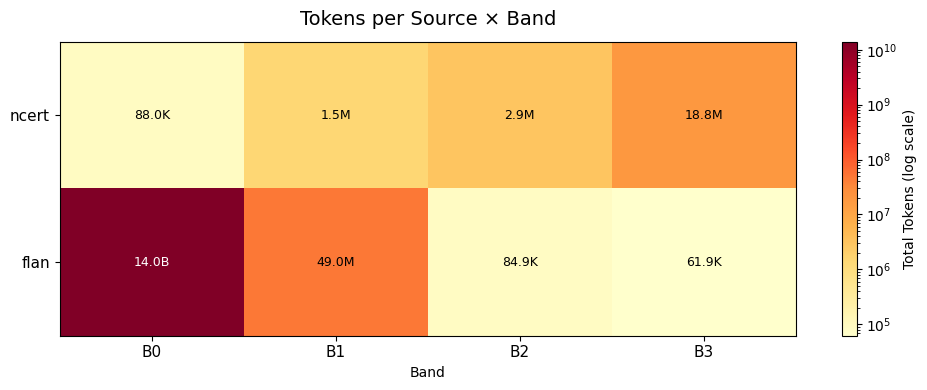

band             B0        B1       B2        B3
source                                          
ncert         88047   1470304  2930219  18836886
flan    14017894653  48982577    84941     61920


In [23]:
# 1) Heatmap – Source × Band (log-scaled token counts)
pivot = df.pivot_table(
    index='source',
    columns='band',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot = pivot[sorted(pivot.columns)]
pivot['_total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('_total', ascending=True).drop(columns='_total')

n_rows, n_cols = pivot.shape
fig, ax = plt.subplots(figsize=(10, max(4, n_rows * 0.5)))

cmap = plt.cm.YlOrRd
log_norm = mcolors.LogNorm(
    vmin=max(pivot.values[pivot.values > 0].min(), 1),
    vmax=pivot.values.max()
)

im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, norm=log_norm)

ax.set_xticks(range(n_cols))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(pivot.index, fontsize=11)

ann_fontsize = adaptive_fontsize(n_rows, n_cols)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot.iloc[i, j]
        if val > 0:
            text = format_tokens(val)
            color = text_color_for_cell(cmap, log_norm, val)
            ax.text(j, i, text, ha='center', va='center', fontsize=ann_fontsize, color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=ann_fontsize, color='gray')

plt.colorbar(im, ax=ax, label='Total Tokens (log scale)')
ax.set_title('Tokens per Source × Band', fontsize=14, pad=12)
ax.set_xlabel('Band')
plt.tight_layout()
fig.savefig('heatmap_tokens_source_band.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_source_band.png")
plt.show()

print(pivot.to_string())

Saved: barh_tokens_source_band.png


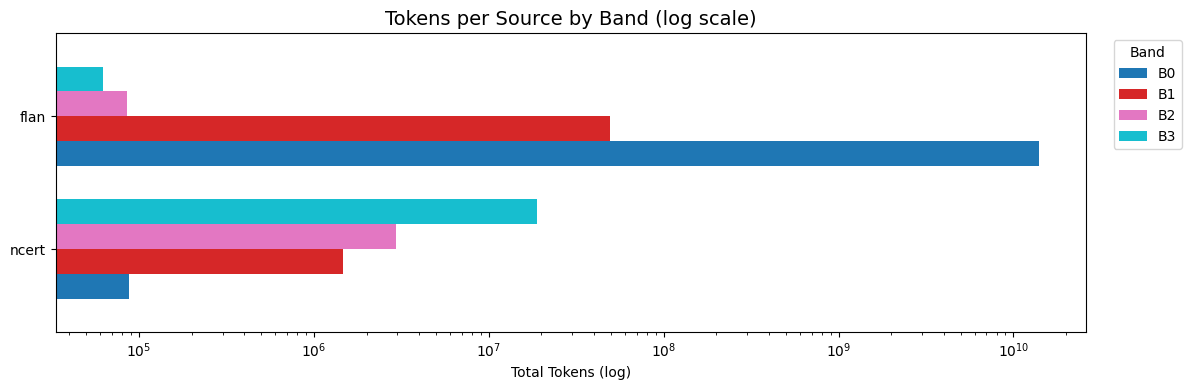

Source   Total Tokens
  flan 14,067,024,091
 ncert     23,325,456


In [12]:
# 2) Horizontal Stacked Bar – Total tokens per source, segmented by band (log scale)
pivot_h = df.pivot_table(
    index='source',
    columns='band',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot_h = pivot_h[sorted(pivot_h.columns)]
pivot_h['_total'] = pivot_h.sum(axis=1)
pivot_h = pivot_h.sort_values('_total', ascending=True)
totals = pivot_h['_total']
pivot_h = pivot_h.drop(columns='_total')

fig, ax = plt.subplots(figsize=(12, max(4, len(pivot_h) * 0.45)))

# Use non-stacked horizontal bars (stacked + log doesn't work well)
# Instead plot each source's band breakdown as grouped bars
pivot_h.plot(kind='barh', stacked=False, ax=ax, colormap='tab10', width=0.75)

ax.set_xscale('log')
ax.set_title('Tokens per Source by Band (log scale)', fontsize=14)
ax.set_xlabel('Total Tokens (log)')
ax.set_ylabel('')
ax.legend(title='Band', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
fig.savefig('barh_tokens_source_band.png', dpi=150, bbox_inches='tight')
print("Saved: barh_tokens_source_band.png")
plt.show()

# Summary table
summary = df.groupby('source')['total_tokens'].sum().sort_values(ascending=False).reset_index()
summary.columns = ['Source', 'Total Tokens']
summary['Total Tokens'] = summary['Total Tokens'].apply(lambda x: f'{x:,.0f}')
print(summary.to_string(index=False))

Saved: heatmap_tokens_source_domain.png


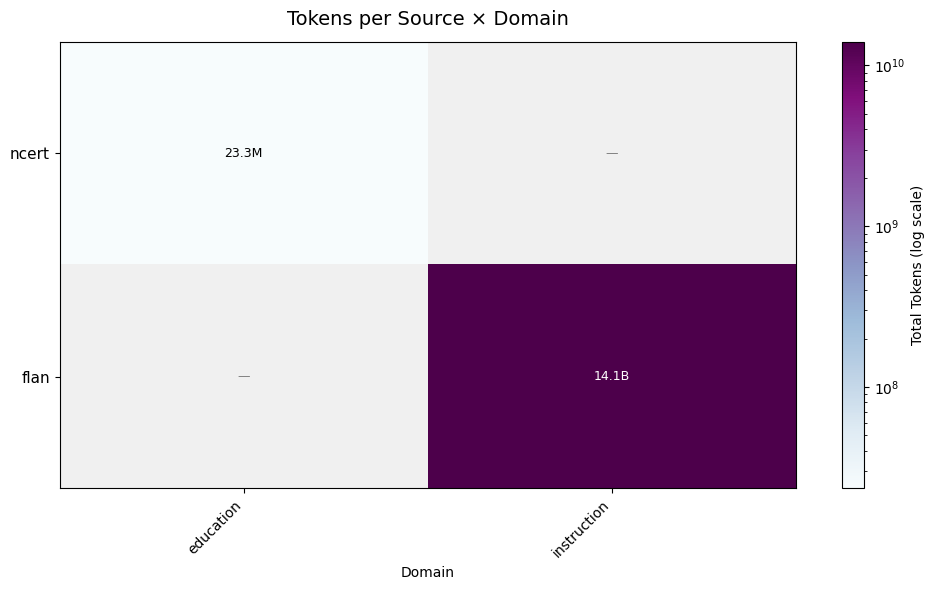

domain  education  instruction
source                        
ncert    23325456            0
flan            0  14067024091


In [24]:
# 3) Heatmap – Source × Domain (log-scaled token counts)
pivot_dom = df.pivot_table(
    index='source',
    columns='domain',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot_dom['_total'] = pivot_dom.sum(axis=1)
pivot_dom = pivot_dom.sort_values('_total', ascending=True).drop(columns='_total')

n_rows, n_cols = pivot_dom.shape
fig, ax = plt.subplots(figsize=(max(10, n_cols * 1.8), max(6, n_rows * 0.55)))

data = pivot_dom.values.astype(float)
masked_data = np.ma.masked_where(data == 0, data)
cmap = plt.cm.BuPu
log_norm = mcolors.LogNorm(
    vmin=max(data[data > 0].min(), 1),
    vmax=data.max()
)

im = ax.imshow(masked_data, aspect='auto', cmap=cmap, norm=log_norm)
ax.set_facecolor('#f0f0f0')

ax.set_xticks(range(n_cols))
ax.set_xticklabels(pivot_dom.columns, fontsize=10, rotation=45, ha='right')
ax.set_yticks(range(n_rows))
ax.set_yticklabels(pivot_dom.index, fontsize=max(8, 11 - n_rows // 10))

ann_fontsize = adaptive_fontsize(n_rows, n_cols)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_dom.iloc[i, j]
        if val > 0:
            text = format_tokens(val)
            color = text_color_for_cell(cmap, log_norm, val)
            ax.text(j, i, text, ha='center', va='center', fontsize=ann_fontsize, color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=ann_fontsize, color='gray')

plt.colorbar(im, ax=ax, label='Total Tokens (log scale)')
ax.set_title('Tokens per Source × Domain', fontsize=14, pad=12)
ax.set_xlabel('Domain')
plt.tight_layout()
fig.savefig('heatmap_tokens_source_domain.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_source_domain.png")
plt.show()

print(pivot_dom.to_string())

Saved: heatmap_tokens_source_language.png


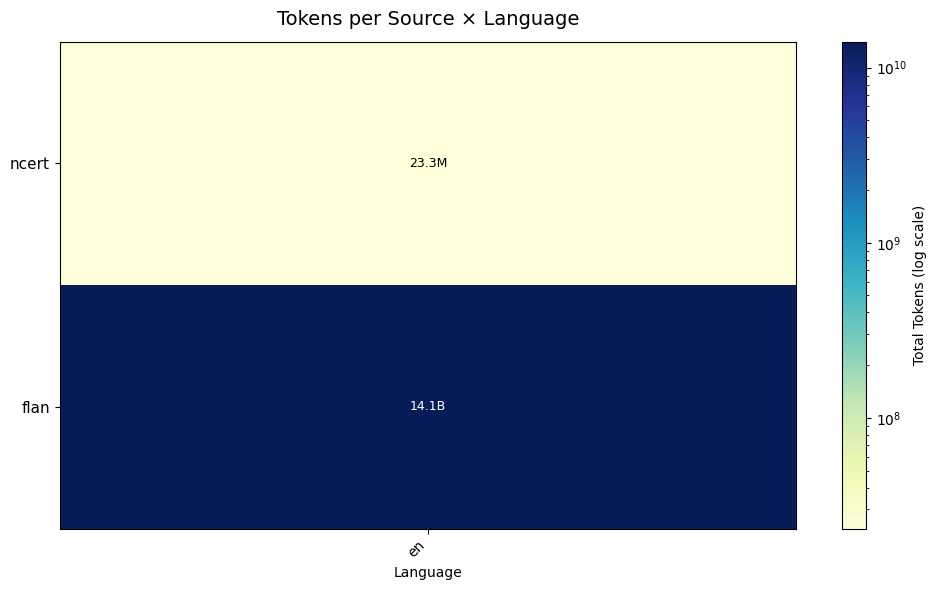

language           en
source               
ncert        23325456
flan      14067024091


In [25]:
# 4) Heatmap – Source × Language (log-scaled token counts)
pivot_lang = df.pivot_table(
    index='source',
    columns='language',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)

pivot_lang['_total'] = pivot_lang.sum(axis=1)
pivot_lang = pivot_lang.sort_values('_total', ascending=True).drop(columns='_total')

n_rows, n_cols = pivot_lang.shape
fig, ax = plt.subplots(figsize=(max(10, n_cols * 1.8), max(6, n_rows * 0.55)))

data = pivot_lang.values.astype(float)
masked_data = np.ma.masked_where(data == 0, data)
cmap = plt.cm.YlGnBu
log_norm = mcolors.LogNorm(
    vmin=max(data[data > 0].min(), 1),
    vmax=data.max()
)

im = ax.imshow(masked_data, aspect='auto', cmap=cmap, norm=log_norm)
ax.set_facecolor('#f0f0f0')

ax.set_xticks(range(n_cols))
ax.set_xticklabels(pivot_lang.columns, fontsize=10, rotation=45, ha='right')
ax.set_yticks(range(n_rows))
ax.set_yticklabels(pivot_lang.index, fontsize=max(8, 11 - n_rows // 10))

ann_fontsize = adaptive_fontsize(n_rows, n_cols)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_lang.iloc[i, j]
        if val > 0:
            text = format_tokens(val)
            color = text_color_for_cell(cmap, log_norm, val)
            ax.text(j, i, text, ha='center', va='center', fontsize=ann_fontsize, color=color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=ann_fontsize, color='gray')

plt.colorbar(im, ax=ax, label='Total Tokens (log scale)')
ax.set_title('Tokens per Source × Language', fontsize=14, pad=12)
ax.set_xlabel('Language')
plt.tight_layout()
fig.savefig('heatmap_tokens_source_language.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_source_language.png")
plt.show()

print(pivot_lang.to_string())

Saved: heatmap_tokens_band_domain.png


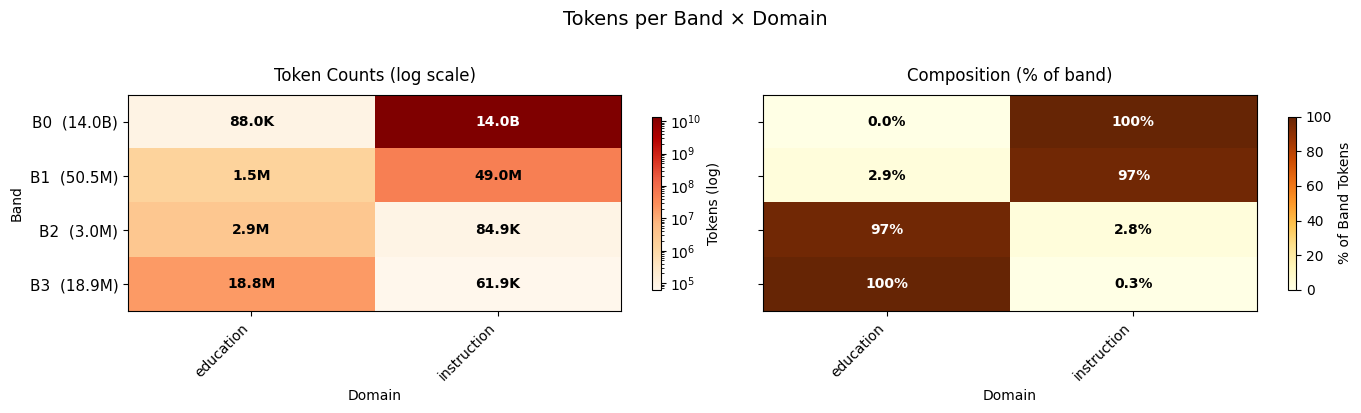


Absolute token counts per band × domain:
domain  education  instruction
band                          
B0          88047  14017894653
B1        1470304     48982577
B2        2930219        84941
B3       18836886        61920

Percentage of tokens per domain within each band:
domain  education  instruction
band                          
B0           0.00       100.00
B1           2.91        97.09
B2          97.18         2.82
B3          99.67         0.33


In [26]:
# 5) Dual Heatmap – Band × Domain (absolute + percentage)
#    Left: log-scaled token counts. Right: % of band tokens per domain.

pivot_bd = df.pivot_table(
    index='band',
    columns='domain',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)
pivot_bd = pivot_bd.sort_index()

# Percentage view
pct_bd = pivot_bd.div(pivot_bd.sum(axis=1), axis=0).fillna(0) * 100

# Shortened band labels
band_totals = pivot_bd.sum(axis=1)
band_labels = [f"{b}  ({format_tokens(band_totals[b])})" for b in pivot_bd.index]

n_rows, n_cols = pivot_bd.shape
panel_width = max(6, n_cols * 1.6)
fig_height = max(4, n_rows * 0.9)
fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(panel_width * 2 + 2, fig_height),
                                       sharey=True)

# --- Left panel: absolute token counts (log scale) ---
data = pivot_bd.values.astype(float)
masked_data = np.ma.masked_where(data == 0, data)
pos_vals = data[data > 0]

cmap_abs = plt.cm.OrRd
if len(pos_vals) > 0:
    log_norm = mcolors.LogNorm(vmin=max(pos_vals.min(), 1), vmax=pos_vals.max())
    im_abs = ax_abs.imshow(masked_data, aspect='auto', cmap=cmap_abs, norm=log_norm)
    plt.colorbar(im_abs, ax=ax_abs, label='Tokens (log)', shrink=0.8)
else:
    im_abs = ax_abs.imshow(data, aspect='auto', cmap=cmap_abs)

ax_abs.set_facecolor('#f0f0f0')
ax_abs.set_xticks(range(n_cols))
ax_abs.set_xticklabels(pivot_bd.columns, fontsize=10, rotation=45, ha='right')
ax_abs.set_yticks(range(n_rows))
ax_abs.set_yticklabels(band_labels, fontsize=11)

ann_fs = adaptive_fontsize(n_rows, n_cols, base=10)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_bd.iloc[i, j]
        if val > 0:
            color = text_color_for_cell(cmap_abs, log_norm, val)
            ax_abs.text(j, i, format_tokens(val), ha='center', va='center',
                        fontsize=ann_fs, color=color, fontweight='bold')
        else:
            ax_abs.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

ax_abs.set_title('Token Counts (log scale)', fontsize=12, pad=10)
ax_abs.set_xlabel('Domain')
ax_abs.set_ylabel('Band')

# --- Right panel: percentage composition (linear 0-100%) ---
cmap_pct = plt.cm.YlOrBr
pct_data = pct_bd.values.astype(float)
masked_pct = np.ma.masked_where(pct_data == 0, pct_data)
pct_norm = mcolors.Normalize(vmin=0, vmax=100)

im_pct = ax_pct.imshow(masked_pct, aspect='auto', cmap=cmap_pct, norm=pct_norm)
ax_pct.set_facecolor('#f0f0f0')

ax_pct.set_xticks(range(n_cols))
ax_pct.set_xticklabels(pivot_bd.columns, fontsize=10, rotation=45, ha='right')

for i in range(n_rows):
    for j in range(n_cols):
        val = pct_bd.iloc[i, j]
        if val > 0:
            label = f'{val:.1f}%' if val < 10 else f'{val:.0f}%'
            color = text_color_for_cell(cmap_pct, pct_norm, val)
            ax_pct.text(j, i, label, ha='center', va='center',
                        fontsize=ann_fs, color=color, fontweight='bold')
        else:
            ax_pct.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

plt.colorbar(im_pct, ax=ax_pct, label='% of Band Tokens', shrink=0.8)
ax_pct.set_title('Composition (% of band)', fontsize=12, pad=10)
ax_pct.set_xlabel('Domain')

fig.suptitle('Tokens per Band × Domain', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('heatmap_tokens_band_domain.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_band_domain.png")
plt.show()

print("\nAbsolute token counts per band × domain:")
print(pivot_bd.to_string())
print("\nPercentage of tokens per domain within each band:")
print(pct_bd.round(2).to_string())

Saved: heatmap_tokens_band_language.png


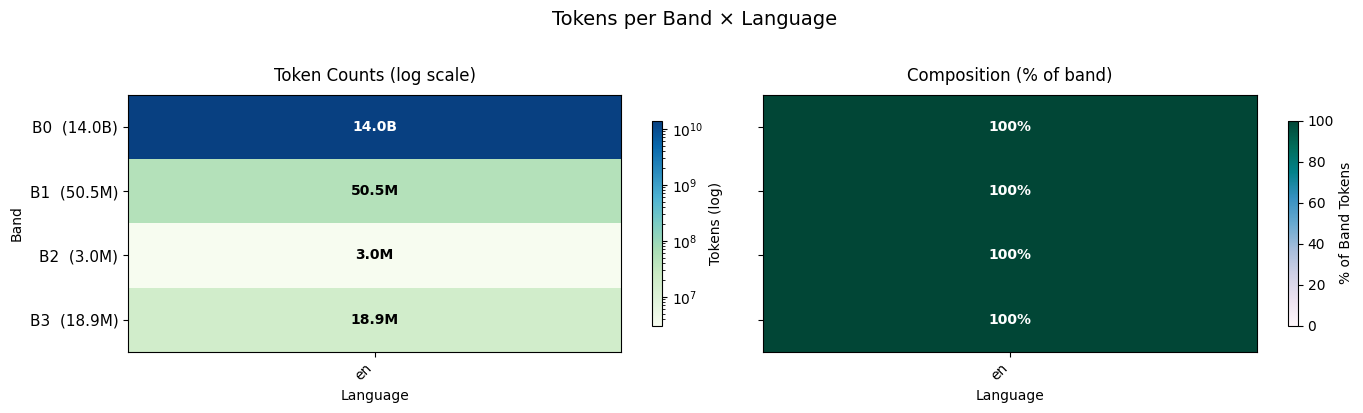


Absolute token counts per band × language:
language           en
band                 
B0        14017982700
B1           50452881
B2            3015160
B3           18898806

Percentage of tokens per language within each band:
language     en
band           
B0        100.0
B1        100.0
B2        100.0
B3        100.0


In [27]:
# 6) Dual Heatmap – Band × Language (absolute + percentage)
#    Left: log-scaled token counts. Right: % of band tokens per language.

pivot_bl = df.pivot_table(
    index='band',
    columns='language',
    values='total_tokens',
    aggfunc='sum',
    fill_value=0
)
pivot_bl = pivot_bl.sort_index()

# Percentage view
pct_bl = pivot_bl.div(pivot_bl.sum(axis=1), axis=0).fillna(0) * 100

# Shortened band labels
band_totals = pivot_bl.sum(axis=1)
band_labels = [f"{b}  ({format_tokens(band_totals[b])})" for b in pivot_bl.index]

n_rows, n_cols = pivot_bl.shape
panel_width = max(6, n_cols * 1.6)
fig_height = max(4, n_rows * 0.9)
fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=(panel_width * 2 + 2, fig_height),
                                       sharey=True)

# --- Left panel: absolute token counts (log scale) ---
data = pivot_bl.values.astype(float)
masked_data = np.ma.masked_where(data == 0, data)
pos_vals = data[data > 0]

cmap_abs = plt.cm.GnBu
if len(pos_vals) > 0:
    log_norm = mcolors.LogNorm(vmin=max(pos_vals.min(), 1), vmax=pos_vals.max())
    im_abs = ax_abs.imshow(masked_data, aspect='auto', cmap=cmap_abs, norm=log_norm)
    plt.colorbar(im_abs, ax=ax_abs, label='Tokens (log)', shrink=0.8)
else:
    im_abs = ax_abs.imshow(data, aspect='auto', cmap=cmap_abs)

ax_abs.set_facecolor('#f0f0f0')
ax_abs.set_xticks(range(n_cols))
ax_abs.set_xticklabels(pivot_bl.columns, fontsize=10, rotation=45, ha='right')
ax_abs.set_yticks(range(n_rows))
ax_abs.set_yticklabels(band_labels, fontsize=11)

ann_fs = adaptive_fontsize(n_rows, n_cols, base=10)
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_bl.iloc[i, j]
        if val > 0:
            color = text_color_for_cell(cmap_abs, log_norm, val)
            ax_abs.text(j, i, format_tokens(val), ha='center', va='center',
                        fontsize=ann_fs, color=color, fontweight='bold')
        else:
            ax_abs.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

ax_abs.set_title('Token Counts (log scale)', fontsize=12, pad=10)
ax_abs.set_xlabel('Language')
ax_abs.set_ylabel('Band')

# --- Right panel: percentage composition (linear 0-100%) ---
cmap_pct = plt.cm.PuBuGn
pct_data = pct_bl.values.astype(float)
masked_pct = np.ma.masked_where(pct_data == 0, pct_data)
pct_norm = mcolors.Normalize(vmin=0, vmax=100)

im_pct = ax_pct.imshow(masked_pct, aspect='auto', cmap=cmap_pct, norm=pct_norm)
ax_pct.set_facecolor('#f0f0f0')

ax_pct.set_xticks(range(n_cols))
ax_pct.set_xticklabels(pivot_bl.columns, fontsize=10, rotation=45, ha='right')

for i in range(n_rows):
    for j in range(n_cols):
        val = pct_bl.iloc[i, j]
        if val > 0:
            label = f'{val:.1f}%' if val < 10 else f'{val:.0f}%'
            color = text_color_for_cell(cmap_pct, pct_norm, val)
            ax_pct.text(j, i, label, ha='center', va='center',
                        fontsize=ann_fs, color=color, fontweight='bold')
        else:
            ax_pct.text(j, i, '—', ha='center', va='center', fontsize=ann_fs, color='gray')

plt.colorbar(im_pct, ax=ax_pct, label='% of Band Tokens', shrink=0.8)
ax_pct.set_title('Composition (% of band)', fontsize=12, pad=10)
ax_pct.set_xlabel('Language')

fig.suptitle('Tokens per Band × Language', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('heatmap_tokens_band_language.png', dpi=150, bbox_inches='tight')
print("Saved: heatmap_tokens_band_language.png")
plt.show()

print("\nAbsolute token counts per band × language:")
print(pivot_bl.to_string())
print("\nPercentage of tokens per language within each band:")
print(pct_bl.round(2).to_string())